In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from src.on_off import (
    pvals_onoff,
    asimov_Zs_onoff,
    expected_significance_onoff,
    median_expected_significance_onoff,
)

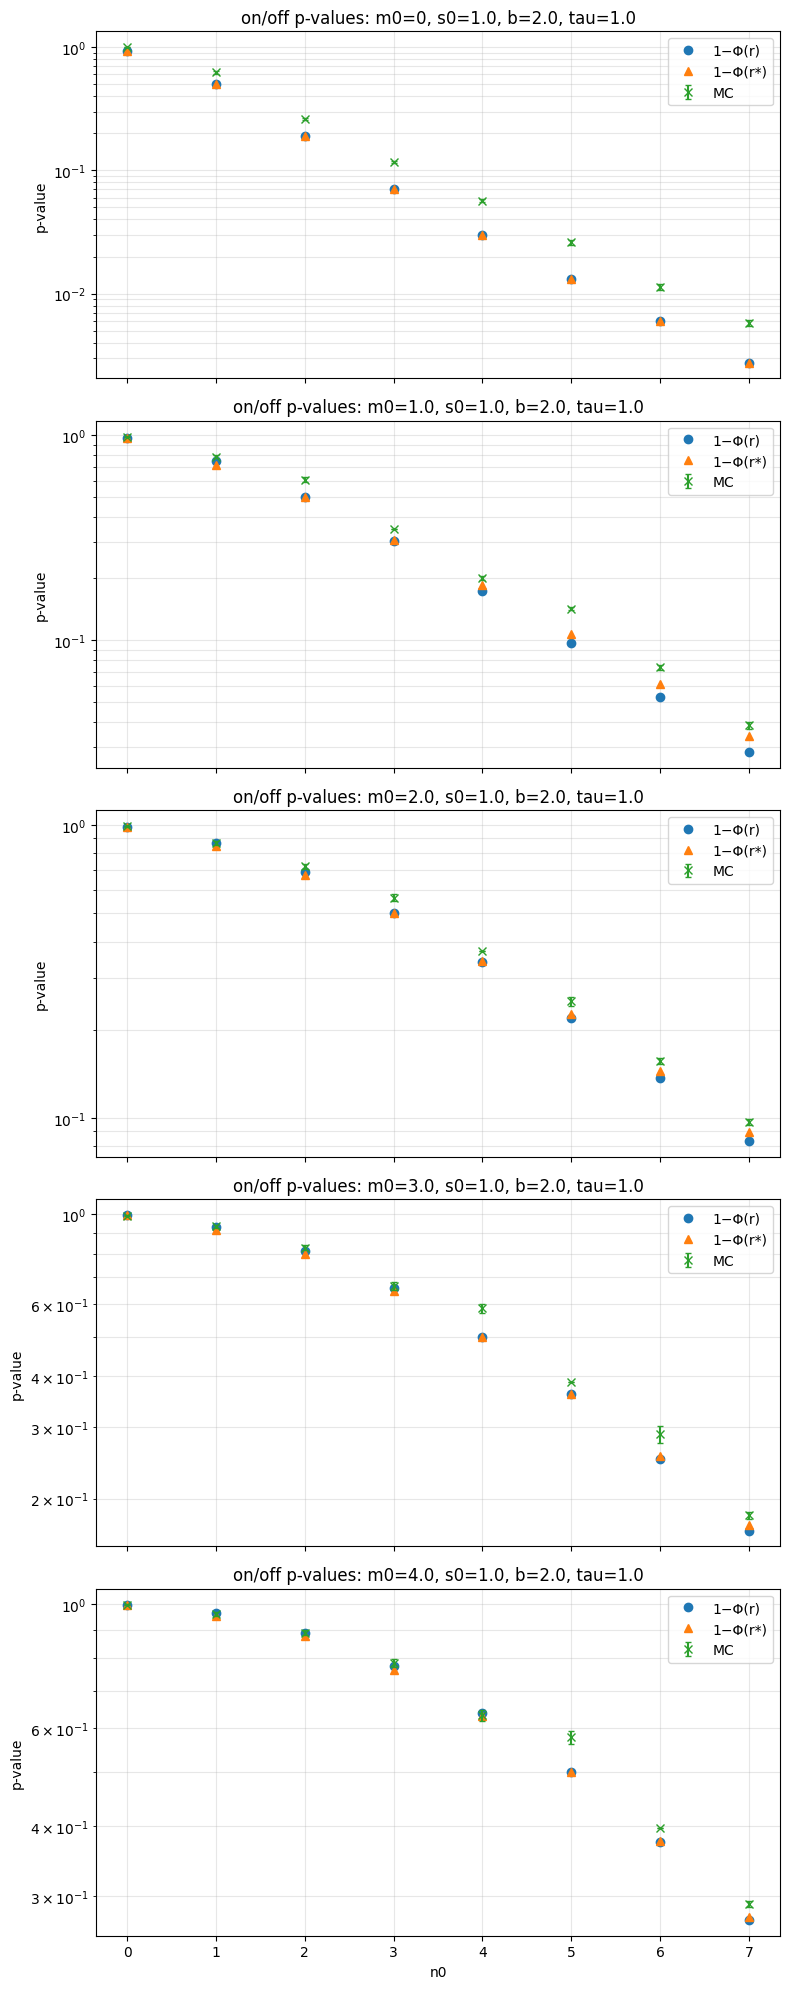

In [6]:
# On/off: single p-value plot

# Set true parameters and number of toys for MC estimation
s0 = 1.0
b = 2.0
tau = 1.0
min_toys = 1000
max_toys = 1000000

mu_s = s0 + b
mu_b = tau * b

# Set observed m0 and n0 values for which to compute p-values
m0_values = [0, 1., 2., 3., 4.]
n0_vals = np.arange(0, 8)

fig, axes = plt.subplots(len(m0_values), 1, figsize=(8, 4*len(m0_values)), sharex=True)
if len(m0_values) == 1:
    axes = [axes]

for ax, m0 in zip(axes, m0_values):
    p_r, p_rs, p_mc, p_err = [], [], [], []
    for n0 in n0_vals:
        # Compute p-values for this (n0, m0)
        out = pvals_onoff(
            s0, b, tau, n0, m0,
            sigrel=0.01,
            min_toys=min_toys,
            max_toys=max_toys,
        )
        p_r.append(out["p_r"])
        p_rs.append(out["p_rstar"])
        p_mc.append(out["p_mc"])
        p_err.append(out["p_mc_se"])
    
    # Avoid exact zeros so semilogy and MC error bars behave nicely
    p_r = np.maximum(p_r, 1e-16)
    p_rs = np.maximum(p_rs, 1e-16)
    p_mc = np.maximum(p_mc, 1e-16)

    ax.semilogy(n0_vals, p_r, marker="o", linestyle="None", label="1−Φ(r)")
    ax.semilogy(n0_vals, p_rs, marker="^", linestyle="None", label="1−Φ(r*)")
    ax.errorbar(n0_vals, p_mc, yerr=p_err, fmt="x", capsize=2, label="MC")
    ax.set_ylabel("p-value")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    ax.set_title(f"on/off p-values: m0={m0}, s0={s0}, b={b}, tau={tau}")

axes[-1].set_xlabel("n0")
plt.tight_layout()
plt.show()

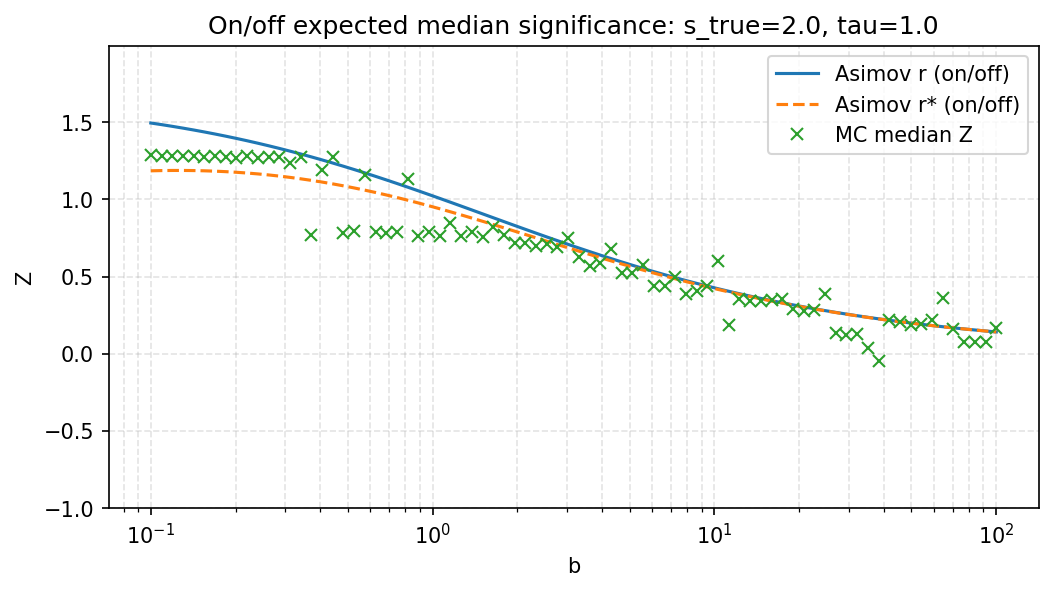

In [13]:
# On/off: compare expected Z as a function of b
s_true = 2.0
tau = 1.0  # off/on exposure ratio
b_values = np.logspace(-1, 2, 80)

# MC setup for the expected-significance estimate
n_outer = 200        # number of outer toys (to estimate median Z)
sigrel = 0.01        # target relative precision for inner toys
min_toys = 1_000     # minimum number of inner toys per (s, b, tau)
max_toys = 1_000_000   # maximum number of inner toys per (s, b, tau)
seed = 12345         # base RNG seed

# Asimov r, Asimov r*, and MC median Z for each b
Z_vals = expected_significance_onoff(
    s_true,
    b_values,
    tau=tau,
    n_outer=n_outer,
    sigrel=sigrel,
    min_toys=min_toys,
    max_toys=max_toys,
    seed=seed,
)

Z_r = Z_vals["Z_A_r"]
Z_rstar = Z_vals["Z_A_rstar"]
Z_mc = Z_vals["Z_mc_median"]

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
ax.plot(b_values, Z_r, label="Asimov r (on/off)")
ax.plot(b_values, Z_rstar, linestyle="--", label="Asimov r* (on/off)")
ax.plot(b_values, Z_mc, linestyle="None", marker="x", label="MC median Z")
ax.set_xscale("log")
ax.set_xlabel("b")
ax.set_ylabel("Z")
ax.set_ylim(bottom=-1, top=max(Z_r.max(), Z_rstar.max(), Z_mc.max()) + 0.5)
ax.grid(True, which="both", ls="--", alpha=0.35)
ax.legend()
ax.set_title(f"On/off expected median significance: s_true={s_true}, tau={tau}")
plt.show()

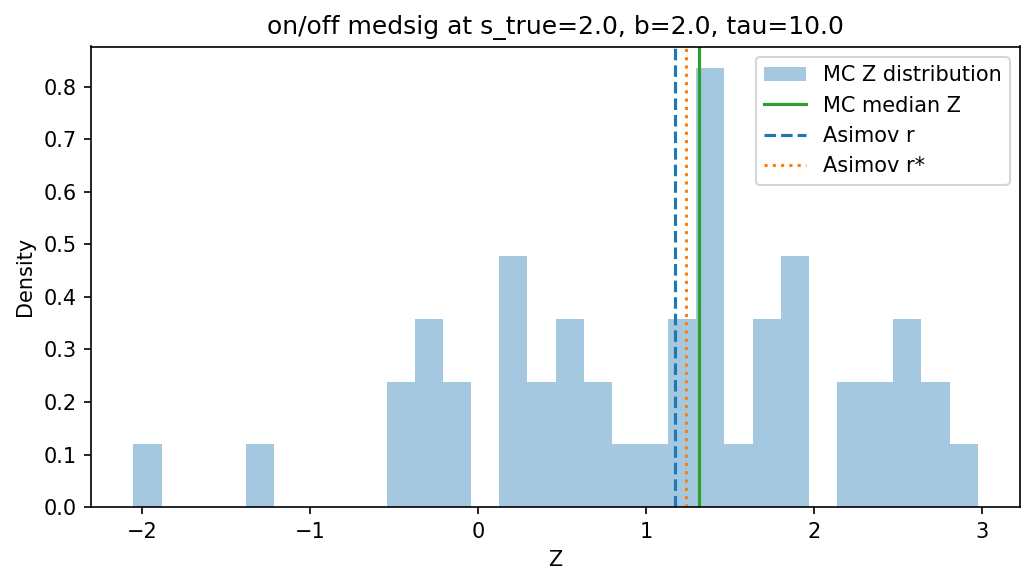

In [10]:
# On/off: compare MC Z distribution with Asimov Z at (s_true, b, tau)
s_true = 2.0
b = 2.0
tau = 10.0

# Settings for the inner toy MC used to estimate each p-value
min_toys = 1000
max_toys = 50000
sigrel = 0.01

# Number of outer toys used to estimate the median Z from MC
n_outer = 50

seed = 1234

# Generate toy (N, M) samples under the alternative hypothesis s_true + b
rng = np.random.default_rng(seed)
Ns = rng.poisson(lam=s_true + b, size=n_outer)
Ms = rng.poisson(lam=tau * b, size=n_outer)

# For each toy, compute an MC p-value under the null hypothesis s = 0
p_list = []
for n_obs, m_obs in zip(Ns, Ms):
    inner_seed = int(rng.integers(1, 2**31 - 1))
    out = pvals_onoff(
        s=0.0,
        b=b,
        tau=tau,
        n=int(n_obs),
        m=int(m_obs),
        sigrel=sigrel,
        min_toys=min_toys,
        max_toys=max_toys,
        seed=inner_seed,
    )
    p = float(out["p_mc"])
    # Allow p to take extreme values (0 or 1); we handle infinities after converting to Z
    p_list.append(p)

# Convert MC p-values to Z; extreme p can give Z = ±inf
Z_samples = norm.isf(p_list)

# Replace ±inf with sentinel values so they can still enter the median
Z_samples_fixed = np.array(Z_samples, copy=True)
Z_samples_fixed[np.isposinf(Z_samples_fixed)] = 999.0
Z_samples_fixed[np.isneginf(Z_samples_fixed)] = -999.0

# Use all Z (including sentinels) to compute the median Z
Z_med = float(np.median(Z_samples_fixed))

# For the plot, exclude only sentinel values (corresponding to p ≈ 0 or 1)
mask_plot = (Z_samples_fixed > -999.0) & (Z_samples_fixed < 999.0)
Z_samples_plot = Z_samples_fixed[mask_plot]

# Asimov Z-values for r and r*
asim = asimov_Zs_onoff(s_true, b, tau)

# Plot MC Z distribution and overlay Asimov r and r*
fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.hist(Z_samples_plot, bins=30, density=True, alpha=0.4, label="MC Z distribution")
ax.axvline(Z_med, color="tab:green", label="MC median Z")
ax.axvline(asim["Z_A_r"], color="tab:blue", linestyle="--", label="Asimov r")
ax.axvline(asim["Z_A_rstar"], color="tab:orange", linestyle=":", label="Asimov r*")
ax.set_xlabel("Z")
ax.set_ylabel("Density")
ax.set_title(f"on/off medsig at s_true={s_true}, b={b}, tau={tau}")
ax.legend()
plt.tight_layout()
plt.show()